In [1]:
import numpy as np
import pandas as pd
data = np.load("../data/c_a/processed/dataset_full.npz", allow_pickle=True)
X_full = data["X"]
df = pd.DataFrame(X_full, columns=[f"F{i}" for i in range(30)])


In [2]:
data["X"][0:5]
df.head()

,F0,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F20,F21,F22,F23,F24,F25,F26,F27,F28,F29
0,16363.0,105177.0,257078.0,112176.0,100136.0,4069.0,12959.0,1438.0,1306.0,11045.0,...,1519.0,14108.0,3908.0,4069.0,14108.0,1838.0,1742.0,12959.0,4611.0,3468.0
1,16381.0,105131.0,256714.0,111976.0,100188.0,3804.0,12314.0,1488.0,1376.0,11906.0,...,1402.0,13614.0,4005.0,3790.0,13614.0,1731.0,1703.0,12314.0,4455.0,3548.0
2,16356.0,104930.0,256160.0,111724.0,100146.0,3884.0,12695.0,1390.0,1374.0,12338.0,...,1465.0,13235.0,3856.0,3858.0,13235.0,1633.0,1729.0,12695.0,4327.0,3591.0
3,16289.0,104516.0,255174.0,111298.0,99772.0,3929.0,12059.0,1332.0,1384.0,12392.0,...,1579.0,13353.0,3942.0,3648.0,13353.0,1645.0,1647.0,12059.0,4360.0,3929.0
4,16337.0,105050.0,256830.0,112078.0,99978.0,3725.0,12668.0,1533.0,1457.0,12386.0,...,1579.0,13251.0,3814.0,3671.0,13251.0,1754.0,1694.0,12668.0,4327.0,3379.0


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = df 
#scaler.fit_transform(df)

In [4]:
from sklearn.decomposition import PCA

pca = PCA(svd_solver="full")
X_pca = pca.fit_transform(X_scaled)

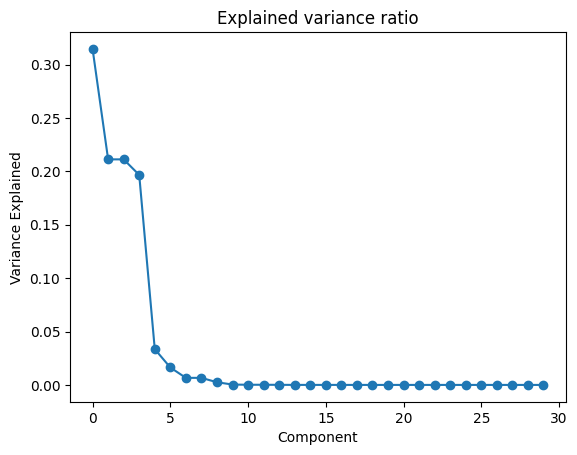

In [5]:
import matplotlib.pyplot as plt

plt.plot(pca.explained_variance_ratio_, marker='o')
plt.title("Explained variance ratio")
plt.xlabel("Component")
plt.ylabel("Variance Explained")
plt.show()

In [6]:
components = pd.DataFrame(
    pca.components_,
    columns = df.columns)

In [7]:
print(pca.explained_variance_)

[3.40174236e+07 2.28354148e+07 2.28354148e+07 2.12594050e+07
 3.62371750e+06 1.76428053e+06 7.15619392e+05 7.15619392e+05
 2.71206159e+05 3.76998630e+04 1.64257378e+04 1.64257378e+04
 8.88409603e+03 2.09081749e+03 1.75508715e+03 1.75508715e+03
 1.51246638e+03 6.76176449e+02 2.21950590e+01 2.21950590e+01
 2.21612416e+01 2.79654877e-23 2.65742515e-23 8.09489604e-24
 1.07132337e-24 8.72758220e-25 2.21209728e-25 2.21209728e-25
 2.21209728e-25 3.01156315e-26]


In [8]:
print(pca.explained_variance_ratio_)
print(pca.singular_values_)

[3.14610867e-01 2.11193820e-01 2.11193820e-01 1.96618061e-01
 3.35140285e-02 1.63169861e-02 6.61842121e-03 6.61842121e-03
 2.50825594e-03 3.48667986e-04 1.51913787e-04 1.51913787e-04
 8.21647516e-05 1.93369702e-05 1.62319609e-05 1.62319609e-05
 1.39880776e-05 6.25363230e-06 2.05271477e-07 2.05271477e-07
 2.04958715e-07 2.58639409e-31 2.45772532e-31 7.48658186e-32
 9.90815705e-33 8.07172300e-33 2.04586289e-33 2.04586289e-33
 2.04586289e-33 2.78525060e-34]
[1.45293412e+07 1.19041849e+07 1.19041849e+07 1.14860517e+07
 4.74211826e+06 3.30886489e+06 2.10734802e+06 2.10734802e+06
 1.29731365e+06 4.83687762e+05 3.19269665e+05 3.19269665e+05
 2.34802024e+05 1.13907751e+05 1.04362520e+05 1.04362520e+05
 9.68808808e+04 6.47776567e+04 1.17360882e+04 1.17360882e+04
 1.17271440e+04 1.31736588e-08 1.28417950e-08 7.08762696e-09
 2.57843094e-09 2.32724544e-09 1.17164846e-09 1.17164846e-09
 1.17164846e-09 4.32305938e-10]


In [9]:
small_components = np.where(pca.explained_variance_ < 1e-4)[0]
components = pca.components_
print(len(small_components))
for i in small_components:
    print(f"\nDependency {i}:")
    print(components[i])

9

Dependency 21:
[ 3.33999605e-01  1.77460971e-01 -4.20818498e-01  5.81997729e-01
  1.84467064e-01  1.24900090e-16 -1.84809225e-03  1.70908781e-01
  1.70908781e-01 -4.87430874e-02 -2.47455222e-02 -2.91433544e-16
  2.16265211e-02  1.70908781e-01  1.70908781e-01 -1.96267803e-01
 -2.47455222e-02 -2.77555756e-17  1.69151237e-01  1.70908781e-01
  1.70908781e-01 -1.35620255e-02 -2.47455222e-02  5.55111512e-17
 -1.35545408e-02  1.70908781e-01  1.70908781e-01 -2.52684740e-02
 -2.47455222e-02 -6.59194921e-17]

Dependency 22:
[-0.00000000e+00  3.57583853e-03 -1.68737560e-02  5.32338752e-03
 -1.82223908e-01 -3.15936513e-16  2.09334112e-01  2.66362051e-02
  2.66362051e-02 -3.38222737e-01  2.30199963e-02  2.64545330e-16
  7.55942963e-01  2.66362051e-02  2.66362051e-02  2.83334625e-01
  2.30199963e-02  1.16118053e-16  1.34385601e-01  2.66362051e-02
  2.66362051e-02  2.08853950e-01  2.30199963e-02  4.82903648e-16
  2.08866276e-01  2.66362051e-02  2.66362051e-02  2.08386114e-01
  2.30199963e-02 -1.65

In [48]:
# import numpy as np
# from sklearn.preprocessing import normalize

# # ── Step 1: SVD on raw integer data ──────────────────────────────────────────
# subset = df.sample(n=2000, random_state=0).astype(int).values.astype(np.float64)
# U, S, Vt = np.linalg.svd(subset, full_matrices=True)

# print("Smallest singular values:")
# for i, s in enumerate(sorted(S)):
#     print(f"  {i}: {s:.6e}")

# # ── Step 2: extract null vectors (rows of Vt where S ~ 0) ────────────────────
# # S has min(m,n) values; Vt has shape (n,n)
# # rows of Vt beyond len(S) are always null; rows where S≈0 are also null
# tol = 1.0  # tune this based on the singular value gap you see above
# null_mask = np.append(S < tol, [True] * (Vt.shape[0] - len(S)))
# null_vecs = Vt[null_mask]  # shape: (nullity, 30)
# print(f"\nNull vectors found: {len(null_vecs)}")

# # ── Step 3: varimax rotation toward sparsity ─────────────────────────────────
# def varimax(V, n_iter=10000):
#     """Rotate rows of V (each row = one null vector) to maximize sparsity."""
#     np.random.seed(42)
#     if len(V) <= 1:
#         return V
#     best = V.copy()
#     best_score = np.sum(best**4)
#     for _ in range(n_iter):
#         i, j = np.random.choice(len(V), 2, replace=False)
#         for theta in np.linspace(0, 2*np.pi, 36):  # grid search angles
#             R = np.eye(len(V))
#             R[i,i] =  np.cos(theta)
#             R[i,j] = -np.sin(theta)
#             R[j,i] =  np.sin(theta)
#             R[j,j] =  np.cos(theta)
#             candidate = R @ V
#             score = np.sum(candidate**4)
#             if score > best_score:
#                 best_score = score
#                 best = candidate
#     return best

# sparse = varimax(null_vecs, n_iter=10000)

# # ── Step 4: print and attempt integer rounding ────────────────────────────────
# feature_names = [f"F{i}" for i in range(30)]
# for k, vec in enumerate(sparse):
#     # normalize so largest = 1
#     vec = vec / vec[np.argmax(np.abs(vec))]
    
#     # try to recover integer ratios by scaling to smallest nonzero
#     nonzero = [c for c in vec if abs(c) > 0.01]
#     min_nz = min(abs(c) for c in nonzero)
#     scaled = vec / min_nz  # scale so smallest coeff ~ 1
#     rounded = np.round(scaled).astype(int)
    
#     # check if rounding was clean
#     residual = np.max(np.abs(scaled - rounded))
    
#     terms = [(feature_names[i], rounded[i]) for i in range(30) if abs(rounded[i]) > 0]
#     pivot = max(terms, key=lambda x: abs(x[1]))
#     rhs = [f"{-c:+d}·{f}" for f, c in terms if f != pivot[0]]
#     flag = "" if residual < 0.1 else f"  ⚠ residual={residual:.3f}"
#     print(f"  Dep {k+1}: {pivot[0]} = {' '.join(rhs)}{flag}")

In [6]:
%%time

from sympy import Matrix, nsimplify

subset = df.sample(n=5000, random_state=0).astype(int)

M = Matrix(subset.values)
ns = M.nullspace()

for v in ns:
    print(v)

Matrix([[10], [-4], [1], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0]])
Matrix([[6], [-2], [0], [1], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0]])
Matrix([[0], [0], [0], [0], [0], [0], [0], [0], [0], [-1], [0], [0], [1], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0]])
Matrix([[0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [-1], [0], [0], [1], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0]])
Matrix([[0], [0], [0], [0], [-1/2], [0], [1], [0], [0], [1], [0], [0], [0], [0], [0], [1], [0], [0], [0], [0], [0], [1], [0], [0], [0], [0], [0], [0], [0], [0]])
Matrix([[0], [0], [0], [0], [-1/2], [0], [1], [0], [0], [1], [0], [0], [0], [0], [0], [1], [0], [0], [0], [0], [0], [0], [0], [0], [1], [0], [0], [0], [0], [0]])
Matrix([[6], [-2], [0], [0], [1], [

In [23]:
from sympy import Matrix, Rational
import numpy as np
import pandas as pd

subset = df.sample(n=5000, random_state=0).astype(int)

# Convert to rational with limited precision to kill floating noise
# Round to e.g. 8 significant figures before handing to SymPy
arr = subset.values
arr_rounded = np.round(arr, 8)  # kills 1e-16 noise

M = Matrix(arr_rounded.tolist())

# rref with a loose pivot threshold so 1e-16 is treated as zero
# iszerofunc controls what SymPy considers "zero" during elimination
rref_mat, pivots = M.rref(iszerofunc=lambda x: abs(x) < 1e-1)

n_cols = arr.shape[1]
all_cols = set(range(n_cols))
free_cols = sorted(all_cols - set(pivots))

print(f"Rank: {len(pivots)}, Nullity: {len(free_cols)}")
print(f"Free (dependent) columns: {free_cols}")

Rank: 21, Nullity: 9
Free (dependent) columns: [2, 3, 12, 18, 21, 24, 26, 27, 28]


In [25]:
import numpy as np
arr = df.sample(n=1000, random_state=0).values.astype(int)

U, S, Vt = np.linalg.svd(arr, full_matrices=False)
print("Singular values (smallest 15):")
for i, s in enumerate(sorted(S)[:15]):
    print(f"  {i}: {s:.6e}")

Singular values (smallest 15):
  0: 2.500625e-10
  1: 9.646110e-10
  2: 9.646110e-10
  3: 9.646110e-10
  4: 9.646110e-10
  5: 9.646110e-10
  6: 9.646110e-10
  7: 9.646110e-10
  8: 9.646110e-10
  9: 1.447501e+02
  10: 1.462874e+02
  11: 1.503482e+02
  12: 7.998941e+02
  13: 1.180377e+03
  14: 1.279585e+03


In [20]:
import numpy as np
from scipy.linalg import null_space

arr = df.sample(n=1000, random_state=0).values

# Check if data is actually integer-valued
print("Are all values integers?", np.all(arr == np.round(arr)))
print("Max deviation from int:", np.max(np.abs(arr - np.round(arr))))

# Convert to exact integers
arr_int = np.round(arr).astype(np.int64)

U, S, Vt = np.linalg.svd(arr_int.astype(float), full_matrices=False)
print("\nSmallest 10 singular values:")
for s in sorted(S)[:10]:
    print(f"  {s:.6e}")

Are all values integers? True
Max deviation from int: 0.0

Smallest 10 singular values:
  2.500625e-10
  9.646110e-10
  9.646110e-10
  9.646110e-10
  9.646110e-10
  9.646110e-10
  9.646110e-10
  9.646110e-10
  9.646110e-10
  1.447501e+02


In [45]:
from sympy import Matrix

arr_int = np.round(df.sample(n=500, random_state=0).values).astype(int)
M = Matrix(arr_int)  

ns = M.nullspace()  
print(f"Nullity: {len(ns)}")
for v in ns:
    # normalize to smallest integer coefficients
    nonzero = [x for x in v if x != 0]
    print(v.T)

Nullity: 9
Matrix([[10, -4, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
Matrix([[6, -2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
Matrix([[0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
Matrix([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
Matrix([[0, 0, 0, 0, -1/2, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]])
Matrix([[0, 0, 0, 0, -1/2, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]])
Matrix([[6, -2, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0]])
Matrix([[0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]])
Matrix([[-1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0]])


In [28]:
f0 = df.iloc[:,0].sum()
f1 = df.iloc[:,1].sum()
f2 = df.iloc[:,2].sum()

print(10*f0-4*f1+f2)

    

0.0


In [29]:
def columnsum(x):
    return df.iloc[:,x].sum()

In [31]:
f3 = columnsum(3)
print(6*f0-2*f1+f3)



0.0


In [33]:

print(-1*columnsum(9) + columnsum(12))

0.0


In [35]:
print(-1*columnsum(15) + columnsum(18))

0.0


In [38]:
print(-1/2*columnsum(4) + columnsum(6)+ columnsum(9)+columnsum(15)+columnsum(21))

0.0


In [39]:
print(-1/2*columnsum(4) + columnsum(6)+ columnsum(9)+columnsum(15)+columnsum(24))

0.0


In [40]:
print(6*columnsum(0) + -2*columnsum(1) + columnsum(4) + columnsum(7) +columnsum(8) + columnsum(13) +columnsum(14) + columnsum(19) +columnsum(20) +columnsum(25) + columnsum(26))

0.0


In [41]:
print(-1*columnsum(6) + columnsum(27))

0.0


In [42]:
print(-columnsum(0) + columnsum(10) +columnsum(16) + columnsum(22) + columnsum(28))

0.0


### Feature Dependencies

$$
F_3 = 4F_2 - 10F_1
$$

$$
F_4 = - 6F_1 + 2F_2 
$$

$$
F_{13} = F_{10}
$$

$$
F_{16} = F_{19} 
$$

$$
F_5 = 2F_7 + 2F_{10} + 2F_{16} + 2F_{22} 
$$

$$
F_5 = 2F_7 + 2F_{10} + 2F_{16} + 2F_{25} 
$$

$$
6F_1 - 2F_2 + F_5 + F_8 + F_9 + F_{14} + F_{15} + F_{20} + F_{21} + F_{26} + F_{27} = 0
$$

$$
F_7 = F_{28} 
$$

$$
F_1 = F_{11} + F_{17} + F_{23} + F_{29} 
$$

$$
F_{22} = F_{25}
$$


In [44]:
print(-columnsum(21) + columnsum(24))

0.0


### Feature Dependencies (Solved Form)

$$
F_3 = 4F_2 - 10F_1
$$

$$
F_4 = 2F_2 - 6F_1
$$

$$
F_{13} = F_{10}
$$

$$
F_{19} = F_{16}
$$


$$
F_{22} = F_{25}
$$

$$
F_{22} = \tfrac{1}{2}F_5 - F_7 - F_{10} - F_{16}
$$

$$
F_{25} = \tfrac{1}{2}F_5 - F_7 - F_{10} - F_{16}
$$

$$
F_5 = -6F_1 + 2F_2 - F_8 - F_9 - F_{14} - F_{15} - F_{20} - F_{21} - F_{26} - F_{27}
$$

$$
F_{28} = F_7
$$

$$
F_{29} = F_1 - F_{11} - F_{17} - F_{23}
$$

In [50]:
coeff = np.array([2, 3, 12, 18, 21, 24, 26, 27, 28])
coeff += 1

print(coeff)


full_array = np.array(0,30)

cols = [0,1,5,6,9,11,15,17,21,23,29]
X_filtered = X_full[:, cols]

[ 3  4 13 19 22 25 27 28 29]


In [ ]:
import os
OUT_DIR = "../data/c_a/processed"
os.makedirs(OUT_DIR, exist_ok=True)

K0_PHASE_C = 4.67
K0_PHASE_A = 4.93
K0_EPS = 1e-6
DOWNSAMPLE = 20


#df_reduced = df.drop(columns=to_drop)
#df_reduced.shape

y_full = data["y"]
K0_full = data["K0"]

X_uncorr = np.asarray(X_filtered)
y_full = np.asarray(y_full, dtype=object)
K0_full = np.asarray(K0_full)

np.savez(
    os.path.join(OUT_DIR, "dataset_full_UNCORR.npz"),
    X=X_uncorr,
    y=y_full,
    K0=K0_full
)

print("dataset_full_UNCORR.npz zapisany")

#print("X_full shape:", X_full.shape)
mask_train = (
    (K0_full == K0_PHASE_C) |
    (K0_full == K0_PHASE_A)
) & (y_full != None)

X_train = X_uncorr[mask_train]
y_train = y_full[mask_train].astype(int)
K0_train = K0_full[mask_train]

# downsampling
idx = np.arange(len(X_train)) % DOWNSAMPLE == 0

X_train = X_train[idx]
y_train = y_train[idx]
K0_train = K0_train[idx]

np.savez(
    os.path.join(OUT_DIR, "dataset_train_shortened_UNCORR.npz"),
    X=X_train,
    y=y_train,
    K0=K0_train
)

print("dataset_train_shortened_UNCORR.npz zapisany")
print("X_train shape:", X_train.shape)
